[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-spectral-type-distribution/notebook.ipynb)

# What kinds of objects has SDSS classified in one small patch of sky?

Rather than looking at one object, this time I queried a whole patch of sky and asked SDSS's own spectral pipeline what it found there -- stars, galaxies, or quasars -- to see the mix. This is a nice sanity check on how survey targeting works: SDSS doesn't observe a random sample of the sky, it deliberately selects targets, so the class mix reflects that.

In [1]:
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
from collections import Counter

query = '''
SELECT TOP 800 class, subclass, z
FROM specObj
WHERE ra BETWEEN 150 AND 152 AND dec BETWEEN 1 AND 3
'''
tab = SDSS.query_sql(query)
print(len(tab), 'spectra found in this patch')
counts = Counter(tab['class'])
print(counts)

800 spectra found in this patch
Counter({'GALAXY': 400, 'STAR': 268, 'QSO': 132})


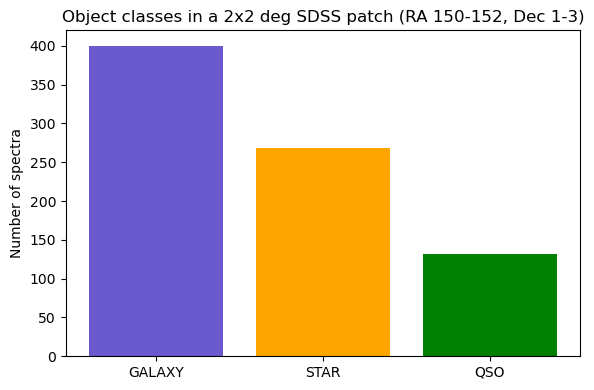

In [2]:
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['slateblue','orange','green'])
plt.ylabel('Number of spectra')
plt.title('Object classes in a 2x2 deg SDSS patch (RA 150-152, Dec 1-3)')
plt.tight_layout()
plt.savefig('class_counts.png', dpi=120)
plt.show()

In [3]:
import numpy as np
galaxies = tab[tab['class']=='GALAXY']
print('Galaxy redshift range:', np.min(galaxies['z']), 'to', np.max(galaxies['z']))
qsos = tab[tab['class']=='QSO']
print('Number of quasars:', len(qsos))
if len(qsos) > 0:
    print('Quasar redshift range:', np.min(qsos['z']), 'to', np.max(qsos['z']))

Galaxy redshift range: 0.003755564 to 0.9871953
Number of quasars: 132
Quasar redshift range: 0.001184321 to 6.567403


Galaxies dominate the spectroscopic counts in this patch, which is typical -- SDSS's main spectroscopic sample was built around a magnitude-limited galaxy survey, with stars and quasars as separate, smaller targeted programs layered on top.

**What I'd look at next:** Compare the class mix in a patch near the Galactic plane, where stars should dominate instead, to see the targeting-footprint effect more starkly.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.